In [1]:
# Check the variables names in the WW3 forcing given by CICE consortium
import xarray as xr
import numpy as np
import pandas as pd
import os
import subprocess
import matplotlib.pyplot as plt

# Import my functions
functions_path = os.path.abspath("/home/566/nd0349/access-om3-analysis/functions")
if functions_path not in sys.path:
    sys.path.append(functions_path)
from get_files import *
from plot_settings import *
from fstd import *
from attenuation_models import *
test()

# ds_ww3.encoding

Functions from get_files.py imported!


In [7]:
files

['/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.1958-01-02-00000.nc',
 '/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.1958-01-03-00000.nc',
 '/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.1958-01-04-00000.nc',
 '/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.1958-01-05-00000.nc',
 '/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.1958-01-06-00000.nc',
 '/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.1958-01-07-00000.nc',
 '/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.1958-01-08-00000.nc',
 '/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.1958-01-09-00000.nc',
 '/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_

In [15]:
files = sorted(glob.glob('/scratch/tm70/ek4684/access-om3/archive/MCW_100km_jra_iaf_IC4_KPP/output000/access-om3.ww3.hi.*000.nc'))

ds_mcw = xr.open_mfdataset(files)
ds_mcw

/jobfs/157749978.gadi-pbs/ipykernel_114415/1166260737.py:3: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_mcw = xr.open_mfdataset(files)


<xarray.Dataset> Size: 576MB
Dimensions:  (time: 31, ny: 300, nx: 360, freq: 25)
Coordinates:
  * time     (time) datetime64[ns] 248B 1958-01-02 1958-01-03 ... 1958-02-01
Dimensions without coordinates: ny, nx, freq
Data variables: (12/17)
    lon      (time, ny, nx) float64 27MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    lat      (time, ny, nx) float64 27MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    mapsta   (time, ny, nx) int32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    UAX      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    UAY      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ICE      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ...       ...
    T01      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    FP0      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    THM      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    EF       (time, freq, ny, nx) float32 335MB dask.array<chunksize=(1, 25, 300, 360), meta=np.ndarray>
    USSX     (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    USSY     (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>

In [17]:
file = '/g/data/rt52/era5/single-levels/reanalysis/swh/1958/swh_era5_wave_sfc_19580101-19580131.nc'
ds_era = xr.open_dataset(file)
ds_era

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 744, latitude: 361, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 6kB 1958-01-01 ... 1958-01-31T23:00:00
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Data variables:
    swh        (time, latitude, longitude) float64 2GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-10 00:29:36 UTC+1000 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis significant_height_of_combine...

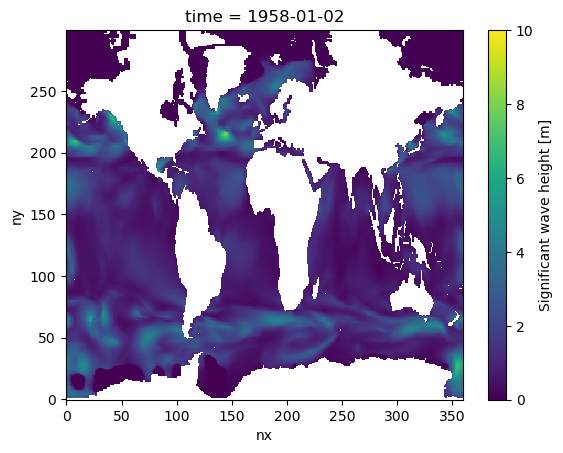

In [18]:
ds_mcw['HS'].roll(nx=-100).isel(time=0).plot(vmax=10)

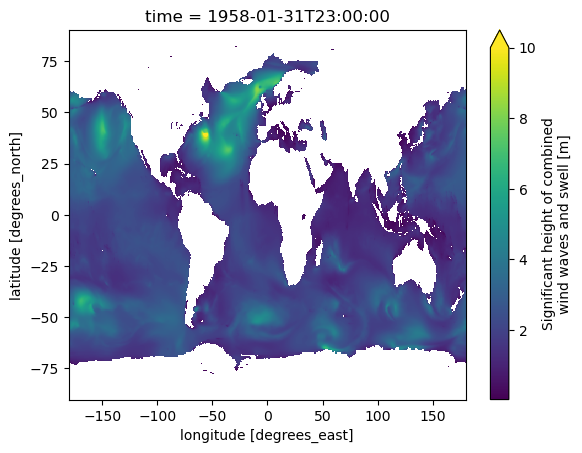

In [19]:
ds_era['swh'].isel(time=-1).plot(vmax=10)

In [20]:
ds_mcw

<xarray.Dataset> Size: 576MB
Dimensions:  (time: 31, ny: 300, nx: 360, freq: 25)
Coordinates:
  * time     (time) datetime64[ns] 248B 1958-01-02 1958-01-03 ... 1958-02-01
Dimensions without coordinates: ny, nx, freq
Data variables: (12/17)
    lon      (time, ny, nx) float64 27MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    lat      (time, ny, nx) float64 27MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    mapsta   (time, ny, nx) int32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    UAX      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    UAY      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ICE      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ...       ...
    T01      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    FP0      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    THM      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    EF       (time, freq, ny, nx) float32 335MB dask.array<chunksize=(1, 25, 300, 360), meta=np.ndarray>
    USSX     (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    USSY     (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>

In [21]:
ds_era

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 744, latitude: 361, longitude: 720)
Coordinates:
  * time       (time) datetime64[ns] 6kB 1958-01-01 ... 1958-01-31T23:00:00
  * latitude   (latitude) float32 1kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
Data variables:
    swh        (time, latitude, longitude) float64 2GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-10 00:29:36 UTC+1000 by era5_replication_tools-1.12...
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...
    title:        ERA5 single-levels reanalysis significant_height_of_combine...

In [22]:
import xesmf as xe
ds_in = ds_era.isel(time=slice(None, None, 24))
ds_out = ds_mcw
rg = xe.Regridder(ds_in, ds_out, method='bilinear', periodic = True, 
                  reuse_weights=False)

ValueError: lon and lat should be both 1D or 2D

In [ ]:
ds_regridded = rg(ds_in)
ds_regridded

In [48]:
ds_era_daily = ds_regridded
ds_era_daily

<xarray.Dataset> Size: 27MB
Dimensions:  (time: 31, ny: 300, nx: 360)
Coordinates:
  * time     (time) datetime64[ns] 248B 1958-01-01 1958-01-02 ... 1958-01-31
Dimensions without coordinates: ny, nx
Data variables:
    swh      (time, ny, nx) float64 27MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    regrid_method:  bilinear

In [49]:
ds_era_daily.time

<xarray.DataArray 'time' (time: 31)> Size: 248B
array(['1958-01-01T00:00:00.000000000', '1958-01-02T00:00:00.000000000',
       '1958-01-03T00:00:00.000000000', '1958-01-04T00:00:00.000000000',
       '1958-01-05T00:00:00.000000000', '1958-01-06T00:00:00.000000000',
       '1958-01-07T00:00:00.000000000', '1958-01-08T00:00:00.000000000',
       '1958-01-09T00:00:00.000000000', '1958-01-10T00:00:00.000000000',
       '1958-01-11T00:00:00.000000000', '1958-01-12T00:00:00.000000000',
       '1958-01-13T00:00:00.000000000', '1958-01-14T00:00:00.000000000',
       '1958-01-15T00:00:00.000000000', '1958-01-16T00:00:00.000000000',
       '1958-01-17T00:00:00.000000000', '1958-01-18T00:00:00.000000000',
       '1958-01-19T00:00:00.000000000', '1958-01-20T00:00:00.000000000',
       '1958-01-21T00:00:00.000000000', '1958-01-22T00:00:00.000000000',
       '1958-01-23T00:00:00.000000000', '1958-01-24T00:00:00.000000000',
       '1958-01-25T00:00:00.000000000', '1958-01-26T00:00:00.000000000',
       '1958-01-27T00:00:00.000000000', '1958-01-28T00:00:00.000000000',
       '1958-01-29T00:00:00.000000000', '1958-01-30T00:00:00.000000000',
       '1958-01-31T00:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 248B 1958-01-01 1958-01-02 ... 1958-01-31

In [50]:
ds_mcw

<xarray.Dataset> Size: 576MB
Dimensions:  (time: 31, ny: 300, nx: 360, freq: 25)
Coordinates:
  * time     (time) datetime64[ns] 248B 1959-11-01 1959-11-02 ... 1959-12-01
Dimensions without coordinates: ny, nx, freq
Data variables: (12/17)
    lon      (time, ny, nx) float64 27MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    lat      (time, ny, nx) float64 27MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    mapsta   (time, ny, nx) int32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    UAX      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    UAY      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ICE      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    ...       ...
    T01      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    FP0      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    THM      (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    EF       (time, freq, ny, nx) float32 335MB dask.array<chunksize=(1, 25, 300, 360), meta=np.ndarray>
    USSX     (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>
    USSY     (time, ny, nx) float32 13MB dask.array<chunksize=(1, 300, 360), meta=np.ndarray>

In [51]:
bias = ds_mcw['HS'] - ds_era_daily['swh']
bias.isel(time=-1).plot()

IndexError: Index -1 is out of bounds for axis 0 with size 0